In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dense,
    ReLU,
    Input
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.1


In [2]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Dataset loaded successfully!")

print("\nTraining data shape :", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing data shape  :", X_test.shape)
print("Testing labels shape :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1887s 11us/step
Dataset loaded successfully!

Training data shape : (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape  : (10000, 32, 32, 3)
Testing labels shape : (10000, 1)


In [3]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print(class_names)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


In [4]:
# Normalize pixel values from [0, 255] to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training pixel range:", X_train.min(), "to", X_train.max())
print("Testing pixel range :", X_test.min(), "to", X_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range : 0.0 to 1.0


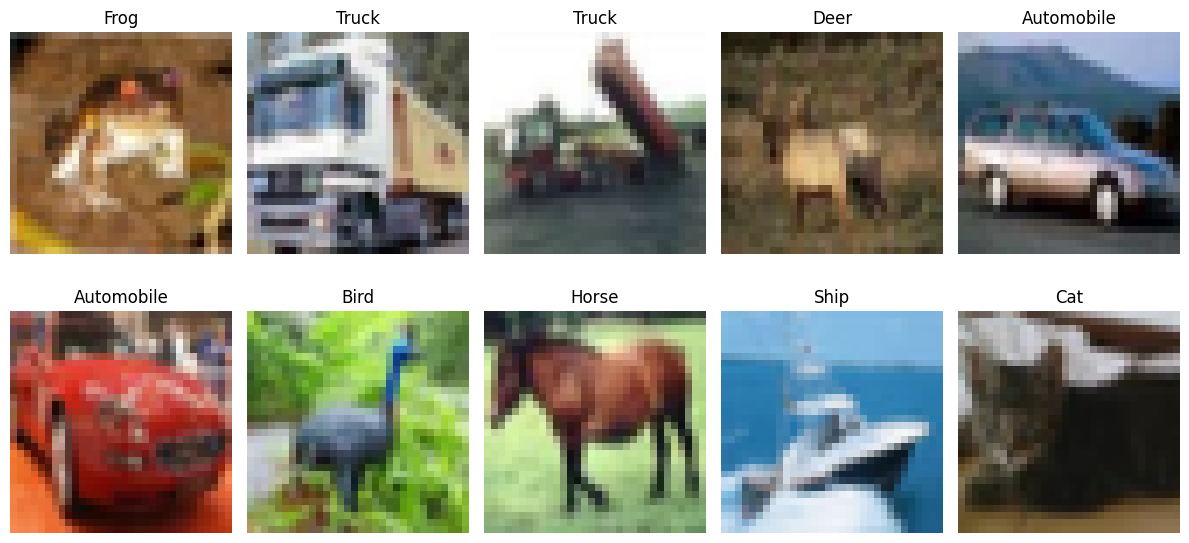

In [5]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("Figures/sample_images.png", dpi=300, bbox_inches="tight")
plt.show()

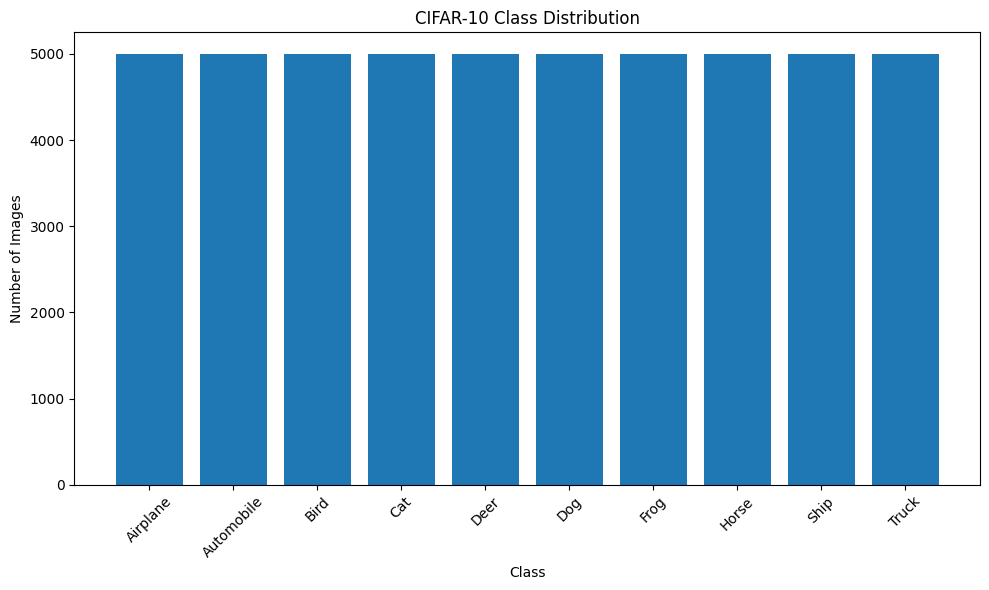

Class distribution:
Airplane    : 5000
Automobile  : 5000
Bird        : 5000
Cat         : 5000
Deer        : 5000
Dog         : 5000
Frog        : 5000
Horse       : 5000
Ship        : 5000
Truck       : 5000


In [6]:
labels = y_train.flatten()

class_counts = np.bincount(labels, minlength=10)

plt.figure(figsize=(10, 6))

plt.bar(class_names, class_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("Figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Class distribution:")
for i in range(10):
    print(f"{class_names[i]:12s}: {class_counts[i]}")

Sample image shape: (32, 32, 3)


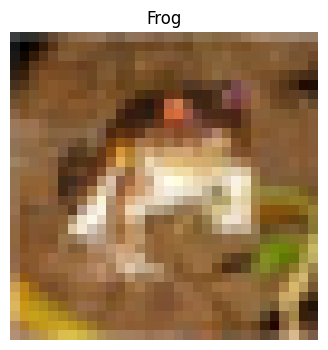

In [7]:
sample_image = X_train[0]

print("Sample image shape:", sample_image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(class_names[y_train[0][0]])
plt.axis("off")
plt.show()

In [8]:
kernel_sizes = [3, 5, 7]

feature_maps = []

for kernel_size in kernel_sizes:

    conv_layer = Conv2D(
        filters=1,
        kernel_size=(kernel_size, kernel_size),
        strides=(1, 1),
        padding="valid",
        use_bias=False
    )

    # Build layer
    conv_layer.build((1, 32, 32, 3))

    # Apply convolution
    output = conv_layer(
        np.expand_dims(sample_image, axis=0)
    )

    feature_maps.append(output.numpy()[0, :, :, 0])

    print(
        f"Kernel {kernel_size}x{kernel_size} "
        f"-> Feature map shape: {output.shape}"
    )

Kernel 3x3 -> Feature map shape: (1, 30, 30, 1)
Kernel 5x5 -> Feature map shape: (1, 28, 28, 1)
Kernel 7x7 -> Feature map shape: (1, 26, 26, 1)


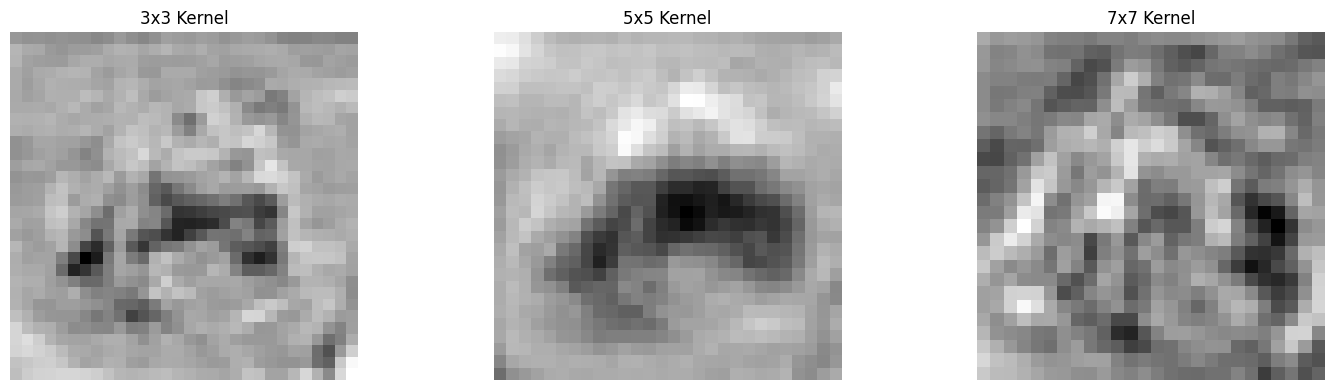

In [9]:
plt.figure(figsize=(15, 4))

for i, kernel_size in enumerate(kernel_sizes):

    plt.subplot(1, 3, i + 1)

    plt.imshow(feature_maps[i], cmap="gray")
    plt.title(f"{kernel_size}x{kernel_size} Kernel")
    plt.axis("off")

plt.tight_layout()
plt.savefig("Figures/convolution_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
stride_results = {}

for stride in [1, 2]:

    conv_layer = Conv2D(
        filters=1,
        kernel_size=(3, 3),
        strides=(stride, stride),
        padding="valid",
        use_bias=False
    )

    conv_layer.build((1, 32, 32, 3))

    output = conv_layer(
        np.expand_dims(sample_image, axis=0)
    )

    stride_results[stride] = output.shape

    print(
        f"Stride = {stride} -> "
        f"Output shape = {output.shape}"
    )

Stride = 1 -> Output shape = (1, 30, 30, 1)
Stride = 2 -> Output shape = (1, 15, 15, 1)


In [11]:
padding_results = {}

for padding in ["valid", "same"]:

    conv_layer = Conv2D(
        filters=1,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding=padding,
        use_bias=False
    )

    conv_layer.build((1, 32, 32, 3))

    output = conv_layer(
        np.expand_dims(sample_image, axis=0)
    )

    padding_results[padding] = output.shape

    print(
        f"Padding = {padding} -> "
        f"Output shape = {output.shape}"
    )

Padding = valid -> Output shape = (1, 30, 30, 1)
Padding = same -> Output shape = (1, 32, 32, 1)


In [12]:
def calculate_output_size(N, F, P, S):
    return (N - F + 2 * P) // S + 1


N = 32
F = 3

print("3x3 kernel, stride 1, valid padding:")
print(calculate_output_size(N, F, 0, 1))

print("\n3x3 kernel, stride 2, valid padding:")
print(calculate_output_size(N, F, 0, 2))

print("\n3x3 kernel, stride 1, same padding:")
P = 1
print(calculate_output_size(N, F, P, 1))

3x3 kernel, stride 1, valid padding:
30

3x3 kernel, stride 2, valid padding:
15

3x3 kernel, stride 1, same padding:
32


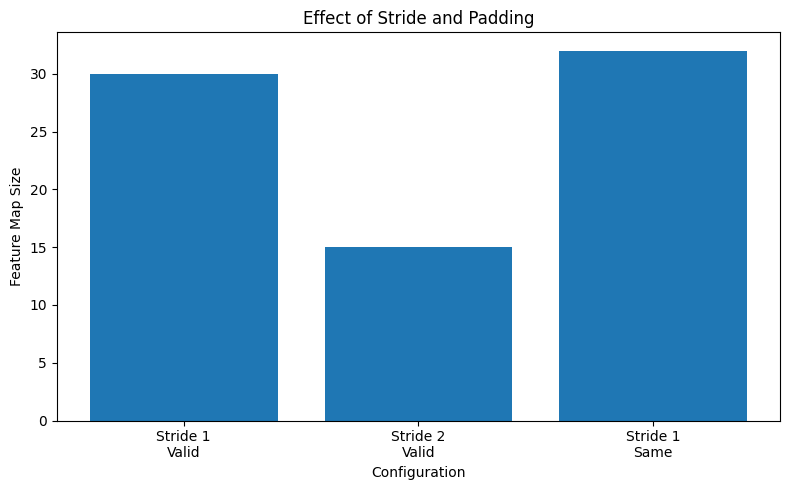

In [13]:
labels = [
    "Stride 1\nValid",
    "Stride 2\nValid",
    "Stride 1\nSame"
]

sizes = [
    30,
    15,
    32
]

plt.figure(figsize=(8, 5))

plt.bar(labels, sizes)

plt.xlabel("Configuration")
plt.ylabel("Feature Map Size")
plt.title("Effect of Stride and Padding")

plt.tight_layout()
plt.savefig("Figures/stride_padding.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
feature_model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
])

feature_output = feature_model.predict(
    np.expand_dims(sample_image, axis=0),
    verbose=0
)

print("Feature map shape:", feature_output.shape)

Feature map shape: (1, 32, 32, 16)


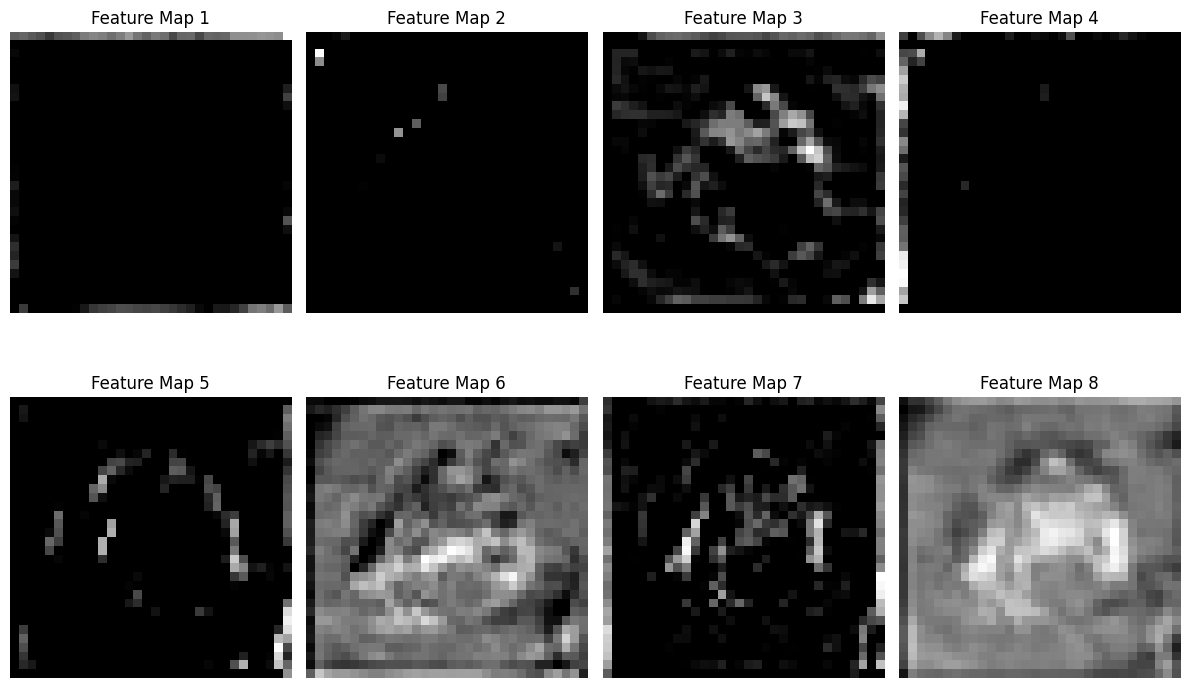

In [15]:
plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(feature_output[0, :, :, i], cmap="gray")
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("Figures/feature_maps.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# Max Pooling
max_pool = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

# Average Pooling
avg_pool = AveragePooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

# feature_output already has the required 4D shape:
# (batch, height, width, channels)

max_output = max_pool(feature_output)
avg_output = avg_pool(feature_output)

print("Original feature map shape :", feature_output.shape)
print("Max pooling output shape   :", max_output.shape)
print("Average pooling output shape:", avg_output.shape)

Original feature map shape : (1, 32, 32, 16)
Max pooling output shape   : (1, 16, 16, 16)
Average pooling output shape: (1, 16, 16, 16)


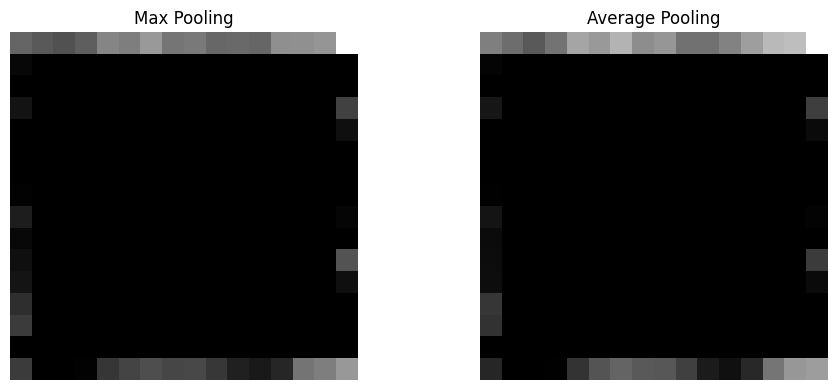

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(max_output[0, :, :, 0], cmap="gray")
plt.title("Max Pooling")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(avg_output[0, :, :, 0], cmap="gray")
plt.title("Average Pooling")
plt.axis("off")

plt.tight_layout()
plt.savefig("Figures/pooling_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
model = Sequential([
    
    Input(shape=(32, 32, 3)),

    # First convolution block
    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    
    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Second convolution block
    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Fully connected layers
    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5071 - loss: 1.3817 - val_accuracy: 0.6108 - val_loss: 1.1133
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.6458 - loss: 1.0087 - val_accuracy: 0.6660 - val_loss: 0.9789
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6953 - loss: 0.8673 - val_accuracy: 0.7026 - val_loss: 0.8772
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7339 - loss: 0.7598 - val_accuracy: 0.6892 - val_loss: 0.8959
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7648 - loss: 0.6745 - val_accuracy: 0.7218 - val_loss: 0.8343
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7933 - loss: 0.5897 - val_accuracy: 0.7156 - val_loss: 0.8602
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.8204 - loss: 0.5110 - val_accuracy: 0.7120 - val_loss: 0.8942
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.8497 -

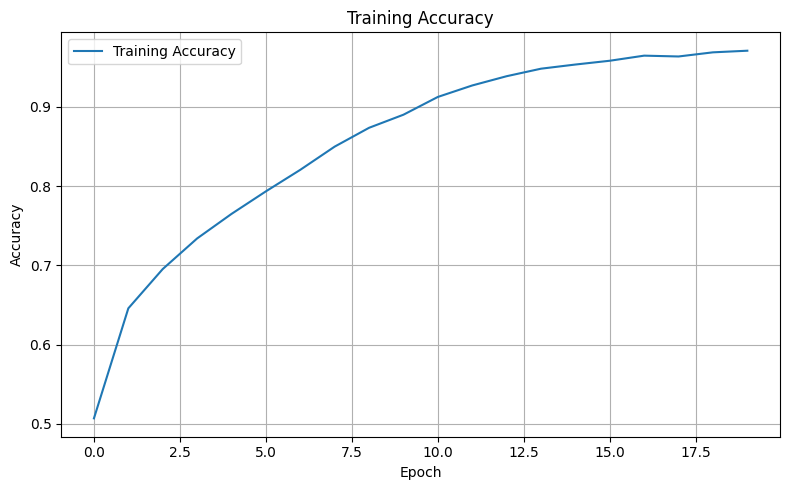

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Figures/training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

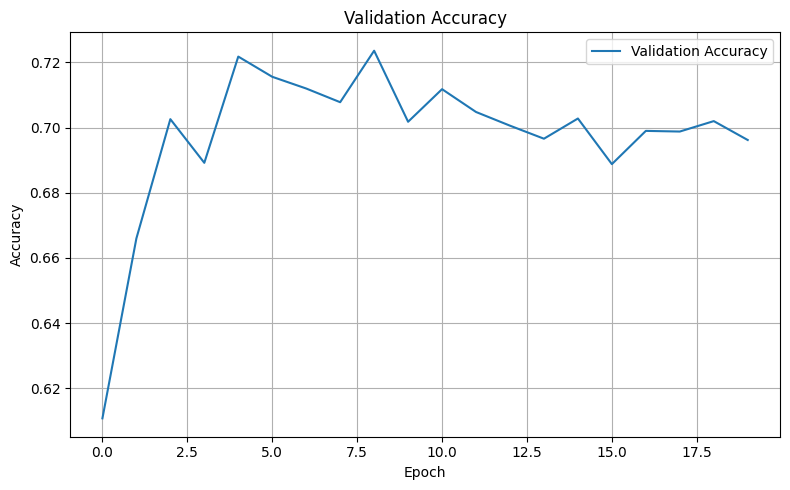

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Figures/validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

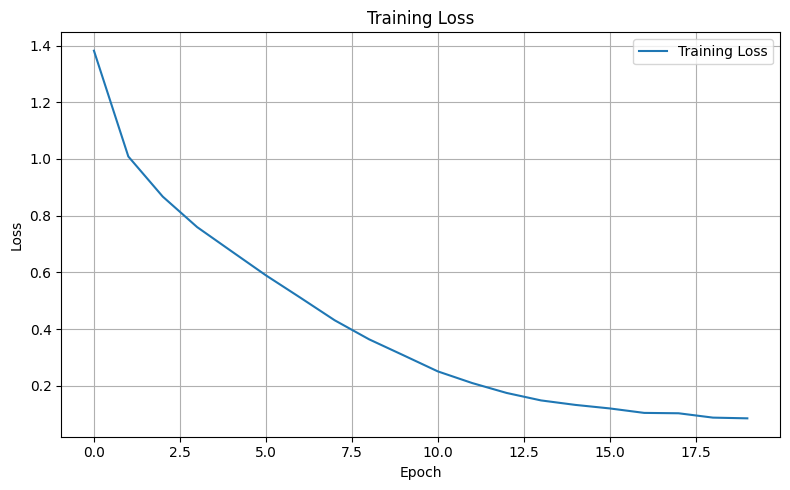

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Figures/training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

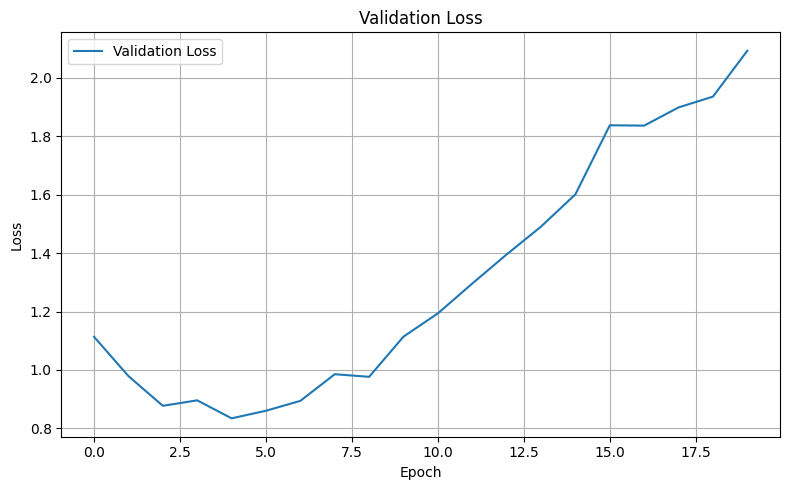

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Figures/validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6804 - loss: 2.2466
Test Loss     : 2.2466037273406982
Test Accuracy : 0.680400013923645


In [27]:
y_probability = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(y_probability, axis=1)

y_true = y_test.flatten()

print("Prediction completed.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Prediction completed.


In [28]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.6804
Precision: 0.6906908810580514
Recall   : 0.6804
F1-score : 0.682831126509971


In [29]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.75      0.70      0.73      1000
  Automobile       0.80      0.77      0.79      1000
        Bird       0.64      0.52      0.57      1000
         Cat       0.46      0.50      0.48      1000
        Deer       0.61      0.62      0.62      1000
         Dog       0.51      0.70      0.59      1000
        Frog       0.74      0.75      0.74      1000
       Horse       0.79      0.71      0.74      1000
        Ship       0.81      0.82      0.81      1000
       Truck       0.80      0.72      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



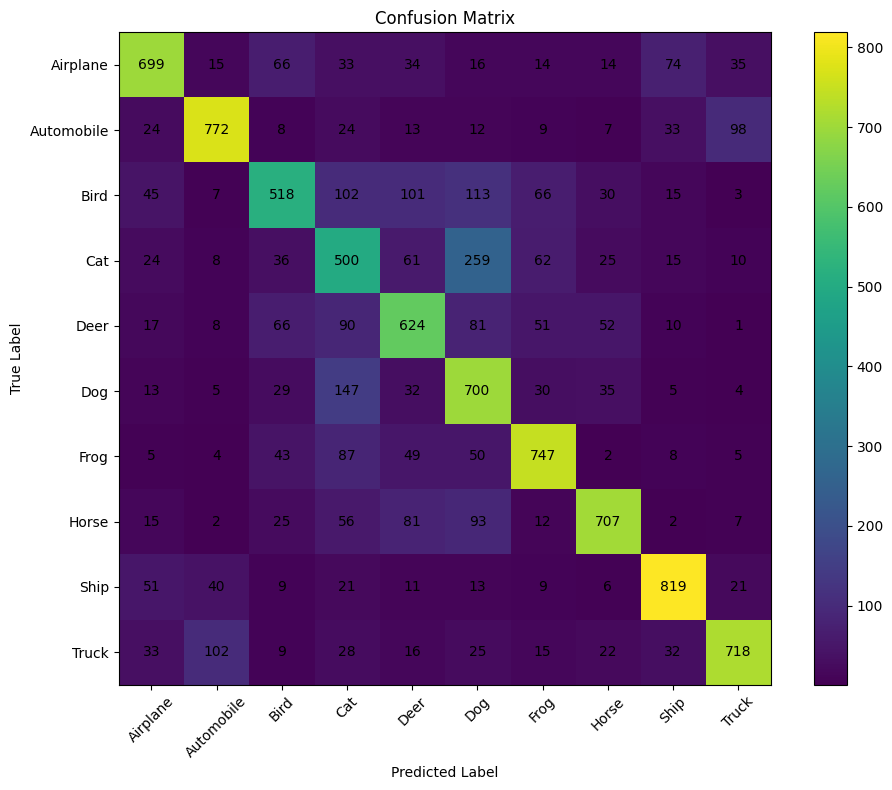

In [30]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(
    np.arange(10),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(10),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Display values
for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig("Figures/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
print("=" * 50)
print("FINAL RESULTS")
print("=" * 50)

print(f"Training Accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Testing Accuracy  : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")

print("\nTotal Parameters:")
print(model.count_params())

FINAL RESULTS
Training Accuracy : 0.9706
Validation Accuracy: 0.6962
Testing Accuracy  : 0.6804
Precision         : 0.6907
Recall            : 0.6804
F1-score          : 0.6828

Total Parameters:
545098
